# The Education Paradox: Gender Gaps in European Higher Education
### An open data analysis using Eurostat data (2022)
*Data source: Eurostat — educ_uoe_grad02, edat_lfse_03*

In [1]:
import eurostat
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go 

In [2]:
# ── PALETTE ──
palette = {
    "Blue": "#2d00f7",
    "Electric Indigo": "#6a00f4",
    "Ultra Violet": "#8900f2",
    "Purple X11": "#a100f2",
    "Purple X11 2": "#b100e8",
    "Hyper Magenta": "#bc00dd",
    "Vivid Orchid": "#d100d1",
    "Vivid Orchid 2": "#db00b6",
    "Electric Rose": "#e500a4",
    "Barbie Pink": "#f20089"
}
pal = list(palette.values())

In [3]:
# ── DATASET 1: Graduates by sex and field of education ──
df_grad = eurostat.get_data_df('educ_uoe_grad02')
print(df_grad.head())
print(df_grad.columns)

  freq unit isced11 iscedf13 sex geo\TIME_PERIOD  2005  2010  2012  2013  ...  \
0    A   NR    ED35      F00   F              AL   NaN   NaN   NaN   NaN  ...   
1    A   NR    ED35      F00   F              AT   NaN   0.0   NaN   NaN  ...   
2    A   NR    ED35      F00   F              BA   NaN   NaN   NaN   NaN  ...   
3    A   NR    ED35      F00   F              BE   0.0   0.0   NaN   NaN  ...   
4    A   NR    ED35      F00   F              BG   0.0   0.0   NaN   NaN  ...   

   2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2   NaN   NaN   NaN   NaN   0.0   0.0   0.0   0.0   0.0   0.0  
3   0.0   0.0   0.0   0.0   0.0  39.0  53.0  55.0   0.0   0.0  
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  

[5 rows x 21 columns]
Index(['freq', 'unit', 'isced11', 'iscedf13', 'sex', 'geo\TIME_PERIOD', '2005',
       '2010', '2012', '20

In [4]:
# ── DATASET 2: Tertiary attainment by sex (% aged 30-34) ──
df_att = eurostat.get_data_df('edat_lfse_03')
print(df_att.head())
print(df_att.columns)

  freq sex  age unit isced11 geo\TIME_PERIOD  1992  1993  1994  1995  ...  \
0    A   F  UNK   PC   ED0-2              AT   NaN   NaN   NaN   NaN  ...   
1    A   F  UNK   PC   ED0-2              BA   NaN   NaN   NaN   NaN  ...   
2    A   F  UNK   PC   ED0-2              BE   NaN   NaN   NaN   NaN  ...   
3    A   F  UNK   PC   ED0-2              BG   NaN   NaN   NaN   NaN  ...   
4    A   F  UNK   PC   ED0-2              CH   NaN   NaN   NaN   NaN  ...   

   2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  
0  37.5  38.4  37.7  35.2  35.5  33.9  35.6  33.6  32.0   NaN  
1   NaN   NaN   NaN   NaN   NaN  64.2  62.3  63.7  61.4   NaN  
2  51.8  50.5  48.7  46.3  44.6  42.4  40.2  38.1  36.6   NaN  
3  33.8  31.3  29.9  28.3  26.0  25.9  25.4  23.4  20.3   NaN  
4  26.8  25.8  23.9  22.4  23.2  24.4  24.1  22.7  23.1   NaN  

[5 rows x 40 columns]
Index(['freq', 'sex', 'age', 'unit', 'isced11', 'geo\TIME_PERIOD', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', 

In [5]:
# Filter for relevant columns and clean
df_grad_clean = df_grad.copy()

# Keep only total frequency, persons unit, ISCED level 6-8 (bachelor+)
df_grad_clean = df_grad_clean[
    (df_grad_clean['freq'] == 'A') &
    (df_grad_clean['unit'] == 'NR') &
    (df_grad_clean['isced11'].isin(['ED6', 'ED7', 'ED8'])) &
    (df_grad_clean['sex'].isin(['F', 'M']))
]

# Rename geo column
df_grad_clean = df_grad_clean.rename(columns={'geo\\TIME_PERIOD': 'country'})

# Keep only recent year — 2022 (most complete)
df_grad_clean = df_grad_clean[['freq', 'unit', 'isced11', 'iscedf13', 'sex', 'country', '2022']]
df_grad_clean = df_grad_clean.rename(columns={'2022': 'value'})

# Drop NaN values
df_grad_clean = df_grad_clean.dropna(subset=['value'])

print(df_grad_clean.shape)
print(df_grad_clean['iscedf13'].unique())  # show fields of study available
print(df_grad_clean['country'].unique())   # show countries available

(38722, 7)
<StringArray>
[  'F00',  'F000',  'F001',  'F002',  'F003',  'F009',   'F01',  'F011',
 'F0110', 'F0111',
 ...
  'F103', 'F1030', 'F1031', 'F1032', 'F1039',  'F104',  'F108',  'F109',
 'TOTAL',   'UNK']
Length: 182, dtype: str
<StringArray>
[       'AL',        'AT',        'BA',        'BE',        'BG',        'CH',
        'CY',        'CZ',        'DE',        'DK',        'EE',        'EL',
        'ES', 'EU27_2020',        'FI',        'FR',        'HR',        'HU',
        'IE',        'IS',        'IT',        'LI',        'LT',        'LU',
        'LV',        'MK',        'MT',        'NL',        'NO',        'PL',
        'PT',        'RO',        'RS',        'SE',        'SI',        'SK',
        'TR']
Length: 37, dtype: str


In [6]:
df_att_clean = df_att.copy()

# Keep age group 25-34 (most standard), percentage unit, EU countries
df_att_clean = df_att_clean[
    (df_att_clean['freq'] == 'A') &
    (df_att_clean['unit'] == 'PC') &
    (df_att_clean['age'] == 'Y25-34') &
    (df_att_clean['sex'].isin(['F', 'M'])) &
    (df_att_clean['isced11'] == 'ED5-8')
]

# Rename geo column
df_att_clean = df_att_clean.rename(columns={'geo\\TIME_PERIOD': 'country'})

# Keep 2022
df_att_clean = df_att_clean[['sex', 'country', '2022']]
df_att_clean = df_att_clean.rename(columns={'2022': 'value'})

# Drop NaN
df_att_clean = df_att_clean.dropna(subset=['value'])

# Remove non-country aggregates
exclude = ['EU27_2020', 'EA20', 'EEA', 'EU28']
df_att_clean = df_att_clean[~df_att_clean['country'].isin(exclude)]

print(df_att_clean.shape)
print(df_att_clean.head(10))

# ── df_att_pivot: for viz 1 (attainment by country) ──
df_att_pivot = df_att_clean.pivot_table(
    index='country', columns='sex', values='value'
).reset_index()
df_att_pivot.columns = ['country', 'F', 'M']
df_att_pivot = df_att_pivot.dropna()
df_att_pivot['gap'] = df_att_pivot['F'] - df_att_pivot['M']

(70, 3)
     sex country  value
3831   F      AT   47.6
3832   F      BA   32.4
3833   F      BE   58.6
3834   F      BG   40.5
3835   F      CH   52.8
3836   F      CY   68.3
3837   F      CZ   43.1
3838   F      DE   39.3
3839   F      DK   58.3
3841   F    EA21   48.1


In [7]:
# Map the relevant field codes to readable names
stem_fields = {
    'F05': 'Natural Sciences',
    'F06': 'ICT',
    'F07': 'Engineering & Manufacturing',
    'F08': 'Agriculture',
}

non_stem_fields = {
    'F09': 'Health & Welfare',
    'F10': 'Services',
    'F01': 'Education',
    'F02': 'Arts & Humanities',
    'F03': 'Social Sciences & Journalism',
    'F04': 'Business & Law',
}

all_fields = {**stem_fields, **non_stem_fields}

In [8]:
# Filter grad dataset for fields we care about
df_viz = df_grad_clean[
    (df_grad_clean['iscedf13'].isin(all_fields.keys())) &
    (df_grad_clean['isced11'] == 'ED6') &  # Bachelor level
    (df_grad_clean['country'].isin(['IT', 'ES', 'FR', 'DE', 'PL', 'SE', 'NL', 'BE']))  # selection of EU countries
].copy()

# Map field codes to readable names
df_viz['field'] = df_viz['iscedf13'].map(all_fields)

# Add STEM label
df_viz['is_stem'] = df_viz['iscedf13'].isin(stem_fields.keys())

# Pivot to get M and F side by side
df_pivot = df_viz.pivot_table(
    index=['country', 'field', 'is_stem'],
    columns='sex',
    values='value'
).reset_index()

df_pivot.columns = ['country', 'field', 'is_stem', 'F', 'M']
df_pivot = df_pivot.dropna()

# Calculate female share
df_pivot['female_share'] = df_pivot['F'] / (df_pivot['F'] + df_pivot['M']) * 100

print(df_pivot.head(10))
print(df_pivot.shape)

  country                         field  is_stem        F       M  \
0      BE                   Agriculture     True    808.0   477.0   
1      BE             Arts & Humanities    False   3873.0  2281.0   
2      BE                Business & Law    False   8538.0  6966.0   
3      BE                     Education    False   6194.0  1661.0   
4      BE   Engineering & Manufacturing     True   1743.0  5580.0   
5      BE              Health & Welfare    False  14402.0  3844.0   
6      BE                           ICT     True    347.0  2111.0   
7      BE              Natural Sciences     True    805.0  1124.0   
8      BE                      Services    False    635.0   526.0   
9      BE  Social Sciences & Journalism    False   4592.0  1520.0   

   female_share  
0     62.879377  
1     62.934677  
2     55.069659  
3     78.854233  
4     23.801721  
5     78.932369  
6     14.117168  
7     41.731467  
8     54.694229  
9     75.130890  
(80, 6)


## 1. Women outpace men in tertiary education across Europe

Across almost every European country, women aged 25-34 are more 
likely than men to hold a tertiary education degree. This is not 
a marginal difference — in many Eastern and Northern European 
countries the gap exceeds 15 percentage points. Countries like 
Lithuania, Latvia and Slovenia show some of the largest gaps in 
favour of women.

This pattern challenges a common assumption: the gender gap in 
education is no longer about access. Women are not being left 
behind in universities — in fact, they are leading. And yet, as 
we will see, this academic success does not translate equally 
across all fields of study.

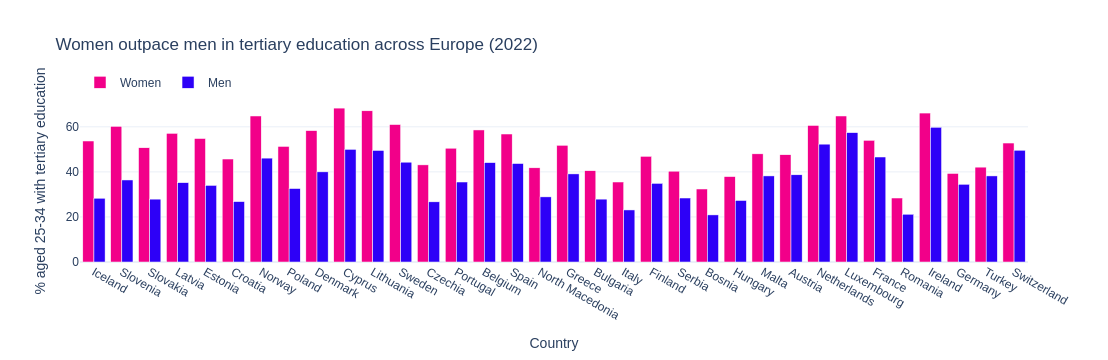

In [9]:
# ── VIZ 1: Grouped bar — Women vs Men attainment ──
country_names_full = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria',
    'CH': 'Switzerland', 'CY': 'Cyprus', 'CZ': 'Czechia',
    'DE': 'Germany', 'DK': 'Denmark', 'EE': 'Estonia',
    'EL': 'Greece', 'ES': 'Spain', 'FI': 'Finland',
    'FR': 'France', 'HR': 'Croatia', 'HU': 'Hungary',
    'IE': 'Ireland', 'IS': 'Iceland', 'IT': 'Italy',
    'LT': 'Lithuania', 'LU': 'Luxembourg', 'LV': 'Latvia',
    'MK': 'North Macedonia', 'MT': 'Malta', 'NL': 'Netherlands',
    'NO': 'Norway', 'PL': 'Poland', 'PT': 'Portugal',
    'RO': 'Romania', 'RS': 'Serbia', 'SE': 'Sweden',
    'SI': 'Slovenia', 'SK': 'Slovakia', 'TR': 'Turkey',
    'BA': 'Bosnia', 'ME': 'Montenegro', 'XK': 'Kosovo'
}

# Remove EA21 first
df_att_pivot = df_att_pivot[df_att_pivot['country'] != 'EA21']

# Map country names
df_att_pivot['country'] = df_att_pivot['country'].map(country_names_full).fillna(df_att_pivot['country'])

# Sort by gap
df_att_pivot = df_att_pivot.sort_values('gap', ascending=False)

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=df_att_pivot['country'], y=df_att_pivot['F'],
    name='Women', marker_color=pal[9]  # Barbie Pink
))
fig1.add_trace(go.Bar(
    x=df_att_pivot['country'], y=df_att_pivot['M'],
    name='Men', marker_color=pal[0]  # Blue
))
fig1.update_layout(
    title='Women outpace men in tertiary education across Europe (2022)',
    xaxis_title='Country',
    yaxis_title='% aged 25-34 with tertiary education',
    barmode='group',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    font=dict(family='Arial')
)
fig1.show()




## 2. The STEM gap: where women are still missing

When we break down graduation rates by field of study, a striking 
pattern emerges. Women make up the majority of graduates in 
Education (81.6%), Health & Welfare (79.7%), Social Sciences 
(69.8%) and Arts & Humanities (66.4%). But in STEM fields the 
picture reverses sharply.

Only 1 in 5 ICT graduates across the EU is a woman (19.7%). In 
Engineering & Manufacturing, the figure is 28.2%. Even in Natural 
Sciences — a field with no obvious structural barrier to women's 
participation — women represent just 54.8% of graduates, barely 
above parity.

This is the heart of the education paradox: women are succeeding 
in higher education overall, but are systematically concentrated 
in fields that tend to offer lower salaries, less institutional 
power, and fewer leadership pathways. The gap is not about 
ability — it is about the subtle and structural forces that shape 
which doors feel open to women and which do not.

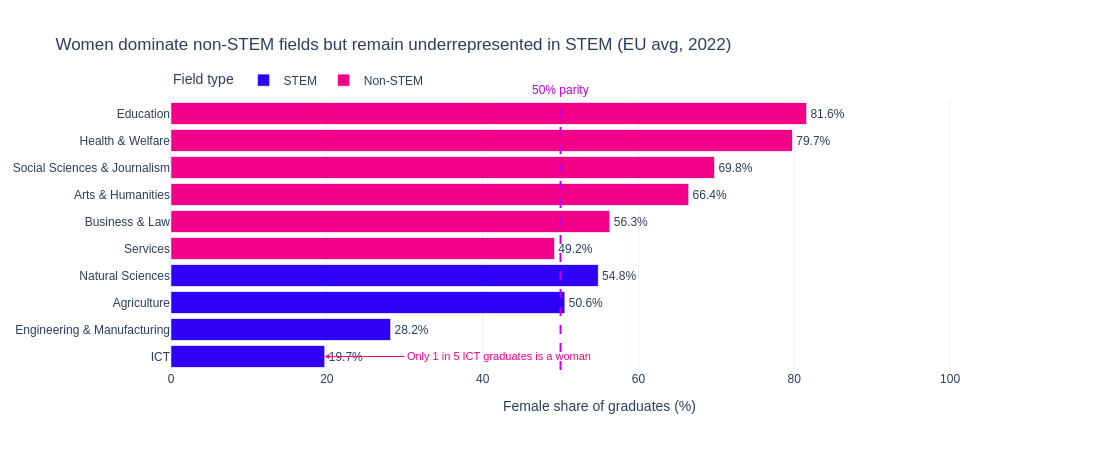

In [10]:
# ── VIZ 2: Horizontal bar — Female share by field ──
# Use gradient: STEM fields get blue end, non-STEM get pink end
df_field_avg = df_pivot.groupby(['field', 'is_stem'])['female_share'].mean().reset_index()
df_field_avg = df_field_avg.sort_values('female_share', ascending=True)
df_field_avg['color'] = df_field_avg['is_stem'].map({
    True: pal[0],   # Blue for STEM
    False: pal[9]   # Barbie Pink for non-STEM
})

fig2 = go.Figure()

# Add bars for STEM fields
stem_data = df_field_avg[df_field_avg['is_stem'] == True]
fig2.add_trace(go.Bar(
    x=stem_data['female_share'],
    y=stem_data['field'],
    orientation='h',
    marker_color=pal[0],  # Blue for STEM
    text=stem_data['female_share'].round(1).astype(str) + '%',
    textposition='outside',
    name='STEM'  # Legend label
))

# Add bars for non-STEM fields
non_stem_data = df_field_avg[df_field_avg['is_stem'] == False]
fig2.add_trace(go.Bar(
    x=non_stem_data['female_share'],
    y=non_stem_data['field'],
    orientation='h',
    marker_color=pal[9],  # Barbie Pink for non-STEM
    text=non_stem_data['female_share'].round(1).astype(str) + '%',
    textposition='outside',
    name='Non-STEM'  # Legend label
))
fig2.add_vline(
    x=50, line_dash='dash',
    line_color=pal[5],  # Hyper Magenta for parity line
    annotation_text='50% parity',
    annotation_position='top',
    annotation_font_color=pal[5]
)
fig2.add_annotation(
    x=19.7, y='ICT',
    text='Only 1 in 5 ICT graduates is a woman',
    showarrow=True,
    arrowhead=2,
    arrowcolor=pal[9],
    font=dict(color=pal[9], size=11),
    xanchor='left',
    ax=80, ay=0
)
fig2.update_layout(
    title='Women dominate non-STEM fields but remain underrepresented in STEM (EU avg, 2022)',
    xaxis_title='Female share of graduates (%)',
    xaxis=dict(range=[0, 110]),
    template='plotly_white',
    height=450,
    font=dict(family='Arial'),
    barmode='overlay', 
    legend=dict(
        title='Field type',
        orientation='h',     
        yanchor='bottom',
        y=1.02,
        xanchor='left',
        x=0
    )

)
fig2.show()


## 3. Is the STEM gap consistent across countries?

The heatmap below shows the female share of STEM graduates broken 
down by country and field. While the overall pattern is consistent 
— ICT and Engineering remain male-dominated everywhere — there is 
meaningful variation across countries.

Poland and Italy show relatively higher female representation in 
Natural Sciences compared to Northern European countries. ICT 
remains the most male-dominated field across all countries without 
exception, suggesting that the barriers to women entering 
technology are structural and cultural rather than country-specific.

This cross-country perspective is important: it shows that the 
gender data gap in STEM is not a local or policy failure of 
individual governments, but a systemic pattern embedded across 
European educational and cultural systems.

<StringArray>
[    'Belgium',     'Germany',       'Spain',      'France',       'Italy',
 'Netherlands',      'Poland',      'Sweden']
Length: 8, dtype: str


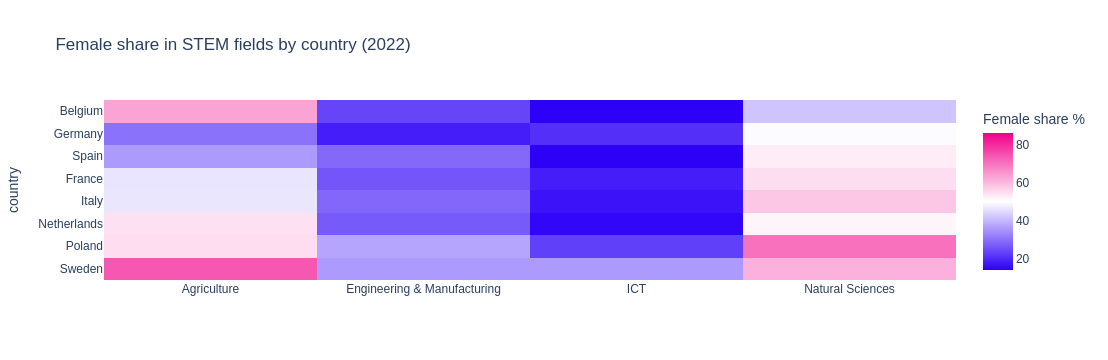

In [11]:
# ── VIZ 3: Heatmap — STEM gap by country ──
# Reset column multiindex first
df_heatmap = df_pivot[df_pivot['is_stem']].pivot_table(
    index='country', columns='field', values='female_share'
).reset_index()

# Flatten column names
df_heatmap.columns.name = None

# Map country names
country_names = {
    'BE': 'Belgium', 'DE': 'Germany', 'ES': 'Spain',
    'FR': 'France', 'IT': 'Italy', 'NL': 'Netherlands',
    'PL': 'Poland', 'SE': 'Sweden'
}
df_heatmap['country'] = df_heatmap['country'].map(country_names)

# Verify mapping worked
print(df_heatmap['country'].unique())

fig3 = px.imshow(
    df_heatmap.set_index('country'),
    color_continuous_scale=[
        [0.0, pal[0]],
        [0.5, '#ffffff'],
        [1.0, pal[9]]
    ],
    color_continuous_midpoint=50,
    title='Female share in STEM fields by country (2022)',
    labels=dict(color='Female share %'),
    aspect='auto'
)
fig3.update_layout(
    template='plotly_white',
    font=dict(family='Arial')
)
fig3.show()

## Conclusions

This analysis reveals a clear and consistent paradox at the heart 
of European higher education:

- **Women are more educated than men** across almost every EU country
- **Yet women remain severely underrepresented in STEM**, particularly 
  in ICT (19.7%) and Engineering (28.2%)
- **This pattern holds across countries**, suggesting structural and 
  cultural barriers rather than country-specific policy failures

The gender data gap in education is therefore not about access to 
university — it is about which knowledge, which skills, and which 
career pathways are implicitly coded as masculine or feminine. 
Addressing this requires not just policy intervention but a 
cultural shift in how we present STEM to young women from the 
earliest stages of education.

### Data sources
- Eurostat: educ_uoe_grad02 — Graduates by sex and field
- Eurostat: edat_lfse_03 — Tertiary attainment by sex

### Tools used
Python — pandas, plotly, eurostat

In [12]:
fig1.write_image("images/attainment.png", scale=2)
fig2.write_image("images/field_gap.png", scale=2)
fig3.write_image("images/heatmap.png", scale=2)
